# nb_full_02 — Basin Transfer Matrix & Domain Distance

**Goal:** Quantify how well a model trained on one basin transfers to another.

- Train **ERM** on each source basin independently (1-vs-1 setup)
- Evaluate on every other basin → **6×6 transfer matrix**
- Metrics: intensity accuracy, direction accuracy, wind MAE (m/s), track ADE (km)
- Compute **CORAL domain distance** between all basin pairs

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import subprocess, sys, importlib, os
from pathlib import Path

subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "netCDF4", "tqdm", "-q"],
               capture_output=True)

TOKEN = ""
REPO  = f"https://{TOKEN}@github.com/Thiruvikraman07/ClimateChangeFinalProject.git"
ROOT  = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT / "final_src") not in sys.path:
    sys.path.insert(0, str(ROOT / "final_src"))
os.chdir(ROOT)

# Clear stale module cache before importing
for _k in list(sys.modules.keys()):
    if _k.startswith(('dataset', 'models', 'methods', 'metrics', 'configs')):
        del sys.modules[_k]

from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")
# ↑ Switch to TrainData for full 6-basin training:
# DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TrainData")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

import dataset.dataset, models.backbone, methods.dg_methods, metrics.basin_metrics
importlib.reload(dataset.dataset)
importlib.reload(models.backbone)
importlib.reload(methods.dg_methods)
importlib.reload(metrics.basin_metrics)

from dataset.dataset import BASIN_CODES, make_dataloader, make_per_basin_loaders
from models.backbone import TropiCycloneModel
from methods.dg_methods import build_method
from metrics.basin_metrics import BasinEvaluator, coral_distance

BASINS = BASIN_CODES
DEVICE = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print(f"Device    : {DEVICE}")
print(f"Basins    : {BASINS}")
print(f"DATA_ROOT : {DATA_ROOT}")


Mounted at /content/drive
Device    : cuda
Basins    : ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']
DATA_ROOT : /content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test


In [2]:
# ── Prefetch Drive → local SSD (skips if already done) ───────────────────────
from dataset.dataset import prefetch_to_local

LOCAL_SSD = Path("/content/tcnd_local")

if (LOCAL_SSD / "Data1D").exists():
    LOCAL_ROOT = str(LOCAL_SSD)
    print(f"Local SSD already populated — skipping copy.")
    print(f"LOCAL_ROOT = {LOCAL_ROOT}")
else:
    _d1d   = Path(DATA_ROOT) / "Data1D"
    _hits  = list(Path(DATA_ROOT).rglob("Data1D")) if not _d1d.exists() else [_d1d]
    _d1d   = _hits[0] if _hits else _d1d
    _votes = []
    for _b in BASINS:
        _bd = _d1d / _b
        if _bd.exists():
            for _p in ["train", "val", "test"]:
                if (_bd / _p).exists(): _votes.append(_p); break
    from collections import Counter as _Ctr
    _split    = _Ctr(_votes).most_common(1)[0][0] if _votes else "test"
    _force_kw = {"force_split": _split} if _split in ("train", "val") else {}
    print(f"Detected split: {_split}")
    LOCAL_ROOT = prefetch_to_local(
        root=DATA_ROOT, basins=BASINS, split=_split,
        local_dir=str(LOCAL_SSD), n_workers=32,
        force_split=_force_kw.get("force_split"),
    )
    print(f"LOCAL_ROOT = {LOCAL_ROOT}")


Detected split: test
Building index to collect file list...
✓ Index loaded from disk cache (12242 samples) — skipping full scan
Files to copy : 24,975  (4.33 GB)
Destination   : /content/tcnd_local
Workers       : 32


Copying to local SSD:   0%|          | 0/24975 [00:00<?, ?file/s]

Done — copied=24,975  skipped=0  errors=0
✓ Use this as DATA_ROOT for fast local training:
  '/content/tcnd_local'
LOCAL_ROOT = /content/tcnd_local


In [3]:
# ── Year-based train/test split ───────────────────────────────────────────────
# On TestData only one folder (test/) exists; we separate train/eval by storm year.
# Matches the approach used in nb_05_final_model.ipynb (TRAIN_YEARS / TEST_YEARS).
import copy as _copy

TRAIN_YEARS = list(range(2017, 2021))   # 2017-2020 → training set
TEST_YEARS  = [2022, 2023]              # 2022-2023 → evaluation set

_all_root = globals().get("LOCAL_ROOT", DATA_ROOT)

# Build full dataset once — SPLIT_ALIASES handles folder fallback automatically
from dataset.dataset import TCNDDataset, tcnd_collate_fn
_ds_full = TCNDDataset(root=_all_root, basins=BASINS, use_3d=True, use_env=True)
print(f"Full index: {len(_ds_full.index)} samples")

def _year_of(meta):
    ts = str(meta.get("timestamp", "0"))
    return int(ts[:4]) if len(ts) >= 4 else 0

_train_idx = [m for m in _ds_full.index if _year_of(m) in TRAIN_YEARS]
_test_idx  = [m for m in _ds_full.index if _year_of(m) in TEST_YEARS]

print(f"Train ({TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]}): {len(_train_idx)} samples")
print(f"Test  {TEST_YEARS}:   {len(_test_idx)} samples")

from collections import Counter as _Ctr
_yr_ctr = _Ctr(_year_of(m) for m in _ds_full.index)
print("\nYear distribution:")
for yr, cnt in sorted(_yr_ctr.items()):
    tag = "TRAIN" if yr in TRAIN_YEARS else ("TEST " if yr in TEST_YEARS else "VAL  ")
    print(f"  {yr}: {cnt:5d}  [{tag}]")


Indexing (parallel):   0%|          | 0/488 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (280660eb11ef.pkl)
Full index: 12242 samples
Train (2017-2020): 8112 samples
Test  [2022, 2023]:   2740 samples

Year distribution:
  2017:  1844  [TRAIN]
  2018:  2632  [TRAIN]
  2019:  2210  [TRAIN]
  2020:  1426  [TRAIN]
  2021:  1390  [VAL  ]
  2022:  1165  [TEST ]
  2023:  1575  [TEST ]


In [4]:
from torch.utils.data import DataLoader as _DL
from methods.dg_methods import task_loss as _task_loss

# ── AMP scaler (no-op on CPU) ─────────────────────────────────────────────────
_USE_AMP  = torch.cuda.is_available()
_AMP_DEV  = "cuda" if _USE_AMP else "cpu"
_scaler   = torch.cuda.amp.GradScaler(enabled=_USE_AMP)
print(f"AMP: {'ON (float16)' if _USE_AMP else 'OFF (CPU — float32)'}")


def _basin_loader(idx_list, basins, batch_size, shuffle):
    """DataLoader from a pre-filtered index list."""
    idx = [m for m in idx_list if m["basin"] in basins]
    if not idx:
        return None
    ds = _copy.copy(_ds_full)
    ds.index = idx
    cuda_avail = torch.cuda.is_available()
    pin_kw = {"pin_memory": cuda_avail}
    if cuda_avail:
        pin_kw["pin_memory_device"] = "cuda"
    nw = 2
    return _DL(
        ds, batch_size=min(batch_size, len(idx)), shuffle=shuffle,
        num_workers=nw, drop_last=(shuffle and len(idx) > batch_size),
        collate_fn=tcnd_collate_fn,
        persistent_workers=(nw > 0), prefetch_factor=(4 if nw > 0 else None),
        **pin_kw,
    )


def quick_train(source_basins, epochs=15, lr=1e-3, batch_size=128, verbose=True):
    """
    Train ERM on source_basins (train years).
    AMP enabled automatically when CUDA is available (~2-3× faster on GPU).
    verbose=False suppresses per-epoch output (used inside greedy inner loop).
    """
    loader = _basin_loader(_train_idx, source_basins, batch_size, shuffle=True)
    if loader is None:
        raise ValueError(f"No train-year data for basins {source_basins}")

    if verbose:
        n_samples = sum(1 for m in _train_idx if m["basin"] in source_basins)
        print(f"\n  Source: {source_basins}  |  train samples: {n_samples}  |  AMP={_USE_AMP}")
        print(f"  {'Ep':>3}  {'Loss':>8}  {'IntAcc':>7}  {'DirAcc':>7}")
        print(f"  {'-'*3}  {'-'*8}  {'-'*7}  {'-'*7}")

    model     = TropiCycloneModel.build(use_3d=True, use_env=True).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    model.train()
    for epoch in range(epochs):
        ep_loss = ep_int = ep_dir = ep_n = 0

        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=_AMP_DEV, enabled=_USE_AMP):
                out  = model(batch)
                loss = _task_loss(
                    out["logits_intensity"], out["logits_direction"],
                    batch["y_intensity"],   batch["y_direction"],
                    pred_reg     = out.get("pred_intensity_reg"),
                    y_wind_reg   = batch.get("y_wind_reg"),
                    y_pres_reg   = batch.get("y_pres_reg"),
                    pred_track   = out.get("pred_track"),
                    y_track_norm = batch.get("y_track_norm"),
                )

            _scaler.scale(loss).backward()
            _scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            _scaler.step(optimizer)
            _scaler.update()

            n        = batch["y_intensity"].size(0)
            ep_loss += loss.item() * n
            ep_int  += (out["logits_intensity"].argmax(1) == batch["y_intensity"]).sum().item()
            ep_dir  += (out["logits_direction"].argmax(1) == batch["y_direction"]).sum().item()
            ep_n    += n

        scheduler.step()
        if verbose and ep_n > 0:
            print(f"  {epoch+1:3d}  {ep_loss/ep_n:8.4f}  {ep_int/ep_n:7.3f}  {ep_dir/ep_n:7.3f}")

    return model


def evaluate(model, test_basin):
    """Evaluate model on test_basin (test years). Returns BasinResult."""
    loader = _basin_loader(_test_idx, [test_basin], 256, shuffle=False)
    ev = BasinEvaluator(test_basin)
    if loader is None:
        return ev.compute()
    model.eval()
    with torch.no_grad(), torch.autocast(device_type=_AMP_DEV, enabled=_USE_AMP):
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            ev.update(batch, model(batch))
    return ev.compute()

print(f"Train index: {len(_train_idx)} samples  |  Test index: {len(_test_idx)} samples")
print("quick_train / evaluate ready.")


AMP: ON (float16)
Train index: 8112 samples  |  Test index: 2740 samples
quick_train / evaluate ready.


/tmp/ipykernel_680/3157333799.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  _scaler   = torch.cuda.amp.GradScaler(enabled=_USE_AMP)


In [ ]:
# ── Build 6×6 transfer matrix ─────────────────────────────────────────────────
QUICK  = True
EPOCHS = 5 if QUICK else 25

results        = {}   # (src, tgt) -> BasinResult
trained_models = {}   # src -> model  (single-basin, for coral-dist etc.)

# Also init _model_cache here so coral-dist / greedy work even if
# this cell runs before the greedy cell defines it.
if '_model_cache' not in dir():
    _model_cache = {}

import time as _time
_t0 = _time.time()

for src in BASINS:
    print(f"\n{'='*60}")
    print(f"  Training on source basin: {src}")
    print(f"{'='*60}")
    model = quick_train([src], epochs=EPOCHS, verbose=True)
    trained_models[src]          = model
    _model_cache[frozenset([src])] = model   # keep cache in sync

    print(f"\n  Evaluating {src}-trained model on all basins:")
    print(f"  {'Target':8s}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  {'ADE(km)':>8}  {'N':>5}")
    print(f"  {'-'*8}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}  {'-'*5}")
    for tgt in BASINS:
        r = evaluate(model, tgt)
        results[(src, tgt)] = r
        marker = " ◀ in-domain" if src == tgt else ""
        print(f"  {tgt:8s}  {r.accuracy_intensity:7.3f}  {r.accuracy_direction:7.3f}  "
              f"{r.mae_wind_ms:8.3f}  {r.ade_km:8.1f}  {r.n_samples:5d}{marker}")

elapsed = _time.time() - _t0
print(f"\n{'='*60}")
print(f"Transfer matrix complete.  ({elapsed/60:.1f} min)")
print(f"Model cache size: {len(_model_cache)}")


In [11]:
# ── Print all four transfer matrices as text ──────────────────────────────────
metrics = [
    ('accuracy_intensity', 'Intensity Accuracy',  '{:6.3f}', False),
    ('accuracy_direction', 'Direction Accuracy',  '{:6.3f}', False),
    ('mae_wind_ms',        'Wind MAE (m/s)',       '{:6.2f}', True),
    ('ade_km',             'Track ADE (km)',       '{:7.1f}', True),
]

for attr, title, fmt, lower_better in metrics:
    direction = 'lower = better' if lower_better else 'higher = better'
    print(f'\n{"="*60}')
    print(f'  {title}  ({direction})')
    print(f'{"="*60}')
    # Header
    print(f'  {"Train→Test":10s}' + ''.join(f'  {b:>7s}' for b in BASINS))
    print('  ' + '-'*58)
    for src in BASINS:
        row = f'  {src:10s}'
        for tgt in BASINS:
            val = getattr(results[(src, tgt)], attr, 0.0)
            cell = fmt.format(val)
            if src == tgt:
                cell = f'[{cell.strip()}]'   # bracket the in-domain diagonal
                row += f'  {cell:>7s}'
            else:
                row += f'  {cell:>7s}'
        print(row)
    print()
    # Row stats
    print(f'  {"Basin":10s}  {"In-domain":10s}  {"Best xfer":10s}  {"Mean xfer":10s}')
    print('  ' + '-'*45)
    for tgt in BASINS:
        in_dom = getattr(results[(tgt, tgt)], attr, 0.0)
        xfer   = [getattr(results[(src, tgt)], attr, 0.0) for src in BASINS if src != tgt]
        best   = min(xfer) if lower_better else max(xfer)
        mean   = sum(xfer) / len(xfer)
        print(f'  {tgt:10s}  {fmt.format(in_dom):>10s}  {fmt.format(best):>10s}  {fmt.format(mean):>10s}')



  Intensity Accuracy  (higher = better)
  Train→Test       WP       NA       EP       NI       SI       SP
  ----------------------------------------------------------
  WP          [0.730]    0.529    0.390    0.714    0.531    0.653
  NA            0.505  [0.376]    0.327    0.464    0.477    0.554
  EP            0.378    0.421  [0.617]    0.571    0.477    0.273
  NI            0.505    0.345    0.327  [0.464]    0.477    0.554
  SI            0.503    0.346    0.327    0.464  [0.477]    0.562
  SP            0.624    0.410    0.360    0.571    0.519  [0.628]

  Basin       In-domain   Best xfer   Mean xfer 
  ---------------------------------------------
  WP               0.730       0.624       0.503
  NA               0.376       0.529       0.410
  EP               0.617       0.390       0.346
  NI               0.464       0.714       0.557
  SI               0.477       0.531       0.496
  SP               0.628       0.653       0.519

  Direction Accuracy  (higher = bett

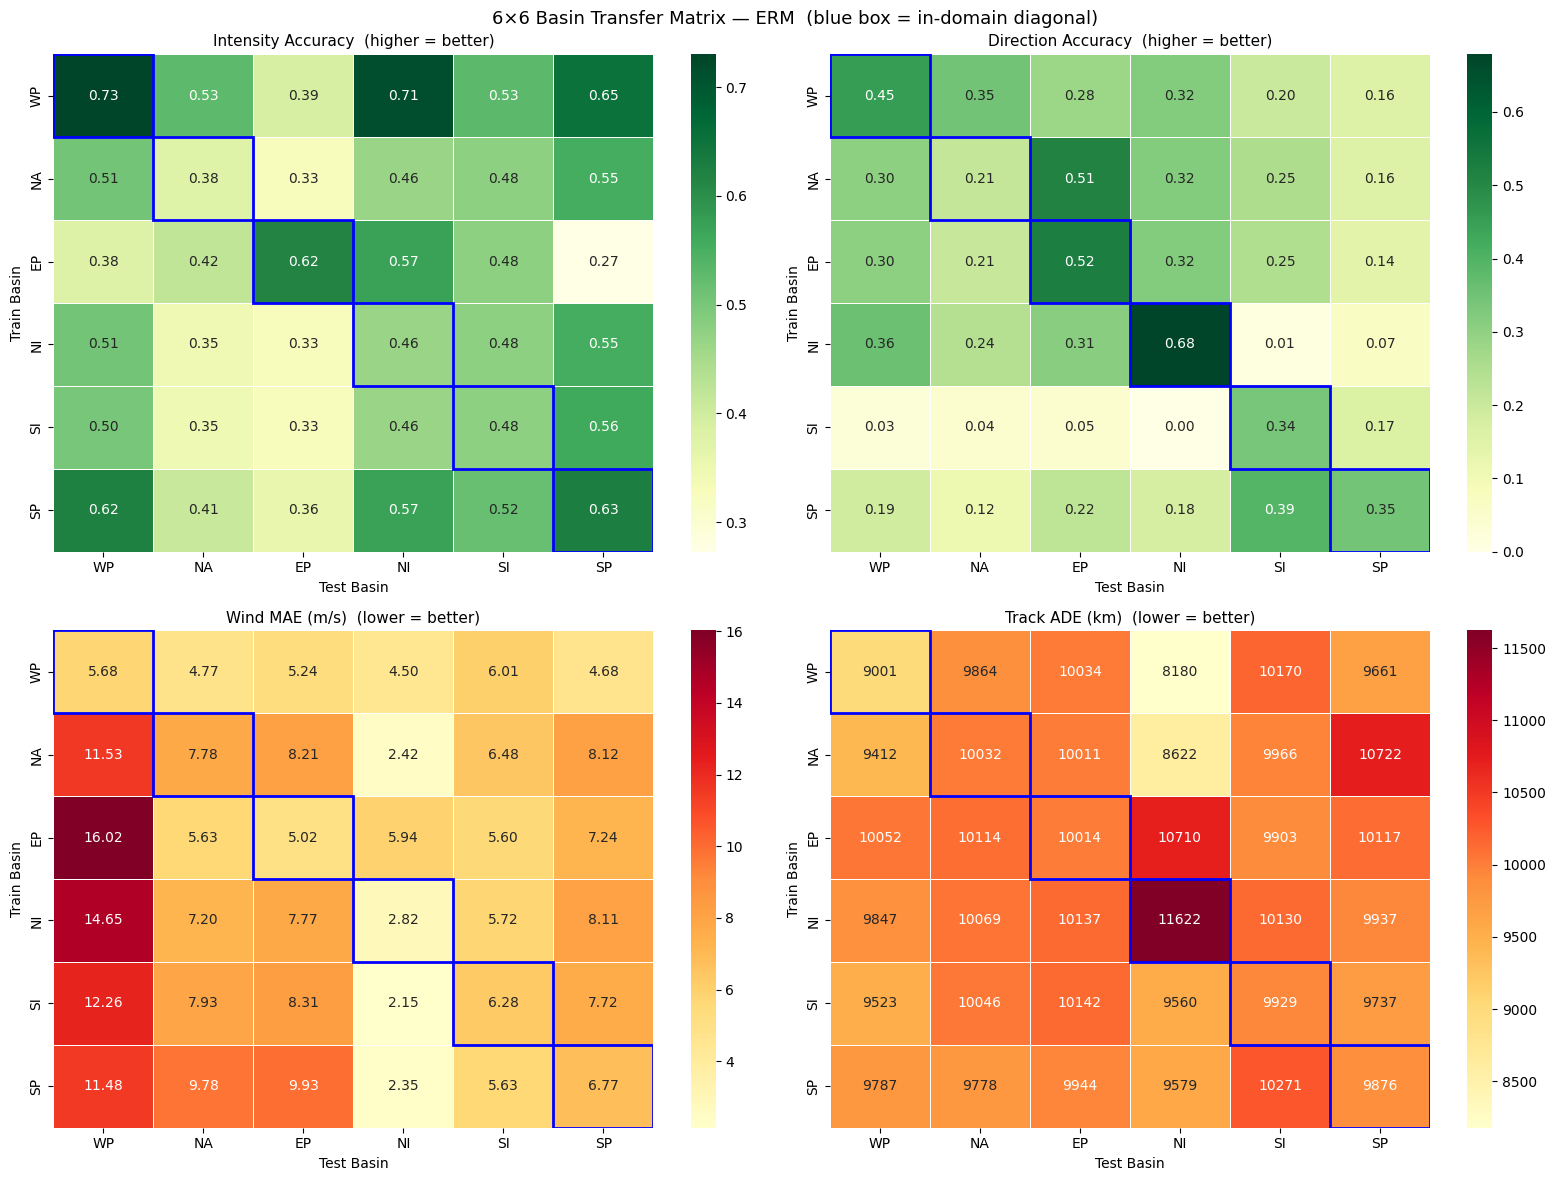

In [12]:
# --- 6×6 heatmaps: all four task metrics ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = [
    ('accuracy_intensity', 'Intensity Accuracy',  '.2f', 'YlGn',   False),
    ('accuracy_direction', 'Direction Accuracy',   '.2f', 'YlGn',   False),
    ('mae_wind_ms',        'Wind MAE (m/s)',        '.2f', 'YlOrRd', True),
    ('ade_km',             'Track ADE (km)',        '.0f', 'YlOrRd', True),
]

for ax, (metric, title, fmt, cmap, lower_better) in zip(axes, metrics):
    mat = np.array([[getattr(results[(src, tgt)], metric, 0.0)
                     for tgt in BASINS] for src in BASINS])
    sns.heatmap(mat, annot=True, fmt=fmt, xticklabels=BASINS,
                yticklabels=BASINS, cmap=cmap, ax=ax,
                linewidths=0.4, linecolor='white')
    direction = '(lower = better)' if lower_better else '(higher = better)'
    ax.set_title(f'{title}  {direction}', fontsize=11)
    ax.set_xlabel('Test Basin'); ax.set_ylabel('Train Basin')
    for k in range(len(BASINS)):
        ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=False,
                                   edgecolor='blue', lw=2))

plt.suptitle('6×6 Basin Transfer Matrix — ERM  (blue box = in-domain diagonal)', fontsize=13)
plt.tight_layout()
plt.savefig('nb_full_02_transfer_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# Transfer gap per target basin: (in-domain acc) - (mean cross-domain acc)
print('Transfer Gap Analysis (Intensity Accuracy):')
print(f'{"Target Basin":14s}  {"In-domain":10s}  {"Cross-domain":13s}  {"Gap":8s}')
print('-' * 55)
for tgt in BASINS:
    in_d  = results[(tgt, tgt)].accuracy_intensity
    cross = np.mean([results[(src, tgt)].accuracy_intensity
                     for src in BASINS if src != tgt])
    print(f'{tgt:14s}  {in_d:.3f}       {cross:.3f}          {in_d-cross:+.3f}')


Transfer Gap Analysis (Intensity Accuracy):
Target Basin    In-domain   Cross-domain   Gap     
-------------------------------------------------------
WP              0.730       0.503          +0.227
NA              0.376       0.410          -0.035
EP              0.617       0.346          +0.270
NI              0.464       0.557          -0.093
SI              0.477       0.496          -0.019
SP              0.628       0.519          +0.109


## Greedy Source Basin Selection

**Question:** For each target basin, what is the *smallest* source-basin combination that achieves near-peak intensity accuracy?

**Method:** Greedy forward selection — start with the single best source, keep adding the basin that gives the biggest improvement, stop when gain < 5% relative.

In [8]:
QUICK  = True
EPOCHS = 5 if QUICK else 25
import time as _time

results       = {}   # (src, tgt) -> BasinResult
trained_models = {}  # src -> trained model  (reused by coral-dist & greedy)

def val_loss(model, target_basin):
    """
    Compute task_loss on the target test set — lower = better source basin.
    Loss = 1.0×CE(int) + 0.5×CE(dir) + 0.5×MSE(wind_reg) + 0.5×MSE(track)
    """
    loader = _basin_loader(_test_idx, [target_basin], 256, shuffle=False)
    if loader is None:
        return float('inf')
    model.eval()
    total_loss = 0.0
    total_n    = 0
    with torch.no_grad(), torch.autocast(device_type=_AMP_DEV, enabled=_USE_AMP):
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            out  = model(batch)
            loss = _task_loss(
                out["logits_intensity"], out["logits_direction"],
                batch["y_intensity"],   batch["y_direction"],
                pred_reg     = out.get("pred_intensity_reg"),
                y_wind_reg   = batch.get("y_wind_reg"),
                y_pres_reg   = batch.get("y_pres_reg"),
                pred_track   = out.get("pred_track"),
                y_track_norm = batch.get("y_track_norm"),
            )
            n           = batch["y_intensity"].size(0)
            total_loss += loss.item() * n
            total_n    += n
    return total_loss / total_n if total_n > 0 else float('inf')


# ── Global model cache — shared across ALL greedy runs ────────────────────────
# Key: frozenset of source basins → trained model
# Pre-populated with single-basin models from build-matrix (free reuse).
_model_cache = {frozenset([b]): m for b, m in trained_models.items()}
print(f"Model cache pre-populated with {len(_model_cache)} single-basin models from build-matrix.")


def _get_or_train(source_set, epochs):
    """Return cached model if available, otherwise train and cache."""
    key = frozenset(source_set)
    if key in _model_cache:
        print(f"    {'+'.join(sorted(source_set)):28s}  [reusing cached model]", flush=True)
        return _model_cache[key]
    model = quick_train(source_set, epochs=epochs, verbose=False)
    _model_cache[key] = model
    return model


def greedy_source_selection(target_basin, max_sources=5, patience_pct=5.0, epochs=None):
    """
    Greedy forward selection using val_loss on the target test set as metric.
    Models are cached globally — if a combination was already trained for a
    previous target's greedy run, it is reused here at zero cost.
    """
    _ep       = epochs if epochs is not None else EPOCHS
    available = [b for b in BASINS if b != target_basin]
    selected  = []
    history   = []
    best_loss = float('inf')

    print(f"\n{'='*72}")
    print(f"  Greedy → {target_basin}  |  metric: val task_loss (lower = better)")
    print(f"  Loss = 1.0×CE(int) + 0.5×CE(dir) + 0.5×MSE(wind_reg) + 0.5×MSE(track)")
    print(f"  Cache size: {len(_model_cache)} models")
    print(f"{'='*72}")
    print(f"  {'Sources':30s}  {'ValLoss':>8}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  {'Δ':>8}")
    print(f"  {'-'*30}  {'-'*8}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")

    _t0 = _time.time()
    for step in range(min(max_sources, len(available))):
        step_best_cand = None
        step_best_loss = float('inf')
        step_best_r    = None

        candidates = [c for c in available if c not in selected]
        cached     = [c for c in candidates if frozenset(selected + [c]) in _model_cache]
        new_       = [c for c in candidates if frozenset(selected + [c]) not in _model_cache]
        print(f"  [step {step+1}] {len(candidates)} candidates — "
              f"{len(cached)} cached, {len(new_)} to train: {new_}", flush=True)

        for candidate in candidates:
            source_set = sorted(selected + [candidate])
            model = _get_or_train(source_set, _ep)
            vl    = val_loss(model, target_basin)
            r     = evaluate(model, target_basin)
            print(f"    {'+'.join(source_set):28s}  loss={vl:.4f}  "
                  f"IntAcc={r.accuracy_intensity:.3f}  DirAcc={r.accuracy_direction:.3f}", flush=True)
            if vl < step_best_loss:
                step_best_loss = vl
                step_best_cand = candidate
                step_best_r    = r

        improvement = ((best_loss - step_best_loss) / max(best_loss, 1e-6)) * 100

        selected.append(step_best_cand)
        available  = [b for b in available if b != step_best_cand]
        best_loss  = step_best_loss
        history.append((list(selected),
                        step_best_r.accuracy_intensity,
                        step_best_r.accuracy_direction,
                        step_best_r.mae_wind_ms,
                        step_best_r.ade_km,
                        step_best_loss))

        delta_str = f"{improvement:+.1f}%" if step > 0 else "   base"
        print(f"  → Selected: {'+'.join(sorted(selected)):28s}  "
              f"loss={step_best_loss:.4f}  IntAcc={step_best_r.accuracy_intensity:.3f}  "
              f"DirAcc={step_best_r.accuracy_direction:.3f}  "
              f"WindMAE={step_best_r.mae_wind_ms:.3f}  Δ={delta_str}")

        if improvement < patience_pct and step > 0:
            print(f"  → Stopping: improvement {improvement:.1f}% < {patience_pct}% threshold")
            break

    elapsed = _time.time() - _t0
    best = history[-1]
    print(f"  Best combo: {'+'.join(sorted(best[0]))}  loss={best[4]:.4f}  "
          f"IntAcc={best[1]:.3f}  DirAcc={best[2]:.3f}  ({elapsed/60:.1f} min)")
    return history


# ── Run greedy for all basins ─────────────────────────────────────────────────
GREEDY_BASINS = BASINS

greedy_results = {}
for tgt in GREEDY_BASINS:
    greedy_results[tgt] = greedy_source_selection(tgt, max_sources=5, patience_pct=5.0)

print(f"\nFinal model cache size: {len(_model_cache)} models")
print("\n\n=== Greedy Selection Summary ===")
print(f"  {'Target':6s}  {'Best Combo':28s}  {'ValLoss':>8}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  {'ADE km':>8}")
print(f"  {'-'*6}  {'-'*28}  {'-'*8}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")
for tgt in GREEDY_BASINS:
    hist  = greedy_results[tgt]
    best  = hist[-1]
    combo = "+".join(sorted(best[0]))
    in_r  = results[(tgt, tgt)]
    in_vl = val_loss(trained_models[tgt], tgt) if tgt in trained_models else float('inf')
    print(f"  {tgt:6s}  {combo:28s}  {best[5]:8.4f}  {best[1]:7.3f}  {best[2]:7.3f}  "
          f"{best[3]:8.3f}  {best[4]:8.1f}  (in-domain loss: {in_vl:.4f})")


Model cache pre-populated with 0 single-basin models from build-matrix.

  Greedy → WP  |  metric: val task_loss (lower = better)
  Loss = 1.0×CE(int) + 0.5×CE(dir) + 0.5×MSE(wind_reg) + 0.5×MSE(track)
  Cache size: 0 models
  Sources                          ValLoss   IntAcc   DirAcc   WindMAE         Δ
  ------------------------------  --------  -------  -------  --------  --------
  [step 1] 5 candidates — 0 cached, 5 to train: ['NA', 'EP', 'NI', 'SI', 'SP']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


    NA                            loss=291.2768  IntAcc=0.505  DirAcc=0.305
    EP                            loss=74.2128  IntAcc=0.360  DirAcc=0.305
    NI                            loss=21.8771  IntAcc=0.505  DirAcc=0.360
    SI                            loss=32.8636  IntAcc=0.505  DirAcc=0.029
    SP                            loss=30.6489  IntAcc=0.546  DirAcc=0.186
  → Selected: NI                            loss=21.8771  IntAcc=0.505  DirAcc=0.360  WindMAE=12.586  Δ=   base
  [step 2] 4 candidates — 0 cached, 4 to train: ['NA', 'EP', 'SI', 'SP']
    NA+NI                         loss=39.4139  IntAcc=0.505  DirAcc=0.360
    EP+NI                         loss=30.3941  IntAcc=0.603  DirAcc=0.290
    NI+SI                         loss=34.5076  IntAcc=0.521  DirAcc=0.305
    NI+SP                         loss=10.1379  IntAcc=0.507  DirAcc=0.337
  → Selected: NI+SP                         loss=10.1379  IntAcc=0.507  DirAcc=0.337  WindMAE=12.546  Δ=+53.7%
  [step 3] 3 candidates — 0 

KeyError: ('WP', 'WP')

In [9]:
### Correct Code
# ── Recovery cell — runs after greedy completes ───────────────────────────────
# Prints greedy summary without depending on `results` dict.
# Uses _model_cache and _get_or_train directly.

print(f"Models in cache: {len(_model_cache)}")
print("  " + ", ".join("+".join(sorted(k)) for k in sorted(_model_cache.keys(), key=len)))

# ── Rebuild in-domain val_loss and accuracy from cached single-basin models ──
print("\n=== In-domain Baseline (from cached models) ===")
print(f"  {'Basin':6s}  {'InDomain ValLoss':>16s}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  {'ADE km':>8}")
print(f"  {'-'*6}  {'-'*16}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")
in_domain = {}
for tgt in BASINS:
    key = frozenset([tgt])
    if key not in _model_cache:
        print(f"  {tgt:6s}  [not in cache — skipping]")
        continue
    m  = _model_cache[key]
    vl = val_loss(m, tgt)
    r  = evaluate(m, tgt)
    in_domain[tgt] = (vl, r)
    print(f"  {tgt:6s}  {vl:16.4f}  {r.accuracy_intensity:7.3f}  "
          f"{r.accuracy_direction:7.3f}  {r.mae_wind_ms:8.3f}  {r.ade_km:8.1f}")

# ── Greedy summary ────────────────────────────────────────────────────────────
print("\n=== Greedy Selection Summary ===")
print(f"  {'Target':6s}  {'Best Combo':28s}  {'ValLoss':>8}  {'IntAcc':>7}  {'DirAcc':>7}  "
      f"{'WindMAE':>8}  {'ADE km':>8}  {'vs In-domain':>12s}")
print(f"  {'-'*6}  {'-'*28}  {'-'*8}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}  {'-'*12}")
for tgt in BASINS:
    if tgt not in greedy_results:
        print(f"  {tgt:6s}  [greedy not run]")
        continue
    hist  = greedy_results[tgt]
    best  = hist[-1]
    combo = "+".join(sorted(best[0]))
    in_vl, in_r = in_domain.get(tgt, (float('inf'), None))
    delta_loss = best[5] - in_vl
    delta_acc  = best[1] - (in_r.accuracy_intensity if in_r else 0)
    note = " ← beats in-domain!" if delta_loss < 0 else ""
    print(f"  {tgt:6s}  {combo:28s}  {best[5]:8.4f}  {best[1]:7.3f}  {best[2]:7.3f}  "
          f"{best[3]:8.3f}  {best[4]:8.1f}  loss {delta_loss:+.4f}  acc {delta_acc:+.3f}{note}")

# ── Per-target greedy history ─────────────────────────────────────────────────
print("\n=== Per-target Greedy Steps ===")
for tgt in BASINS:
    if tgt not in greedy_results:
        continue
    hist = greedy_results[tgt]
    in_vl = in_domain.get(tgt, (float('inf'),))[0]
    print(f"\n  {tgt} (in-domain loss={in_vl:.4f}):")
    for step, h in enumerate(hist):
        combo = "+".join(sorted(h[0]))
        print(f"    step {step+1}: {combo:28s}  loss={h[5]:.4f}  "
              f"IntAcc={h[1]:.3f}  DirAcc={h[2]:.3f}  WindMAE={h[3]:.3f}  ADE={h[4]:.1f}km")


Models in cache: 35
  NA, EP, NI, SI, SP, WP, NA+NI, EP+NI, NI+SI, NI+SP, EP+WP, EP+SI, EP+SP, NA+WP, NA+SI, NA+SP, SI+WP, SP+WP, NI+WP, NA+NI+SP, EP+NI+SP, NI+SI+SP, EP+SI+WP, EP+NI+SI, EP+SI+SP, NA+NI+WP, NA+SI+WP, NA+SP+WP, SI+SP+WP, EP+SP+WP, NI+SP+WP, EP+NI+SI+WP, EP+NI+SI+SP, NA+NI+SI+WP, NA+SI+SP+WP

=== In-domain Baseline (from cached models) ===
  Basin   InDomain ValLoss   IntAcc   DirAcc   WindMAE
  ------  ----------------  -------  -------  --------
  WP                1.7830    0.730    0.479     5.775
  NA                6.6582    0.345    0.201     7.777
  EP                3.1291    0.596    0.531     5.204
  NI               74.0268    0.464    0.679     2.323
  SI                6.2942    0.477    0.340     6.031
  SP                5.0962    0.603    0.124     6.782

=== Greedy Selection Summary ===
  Target  Best Combo                     ValLoss   IntAcc   DirAcc   WindMAE  vs In-domain
  ------  ----------------------------  --------  -------  -------  --------  

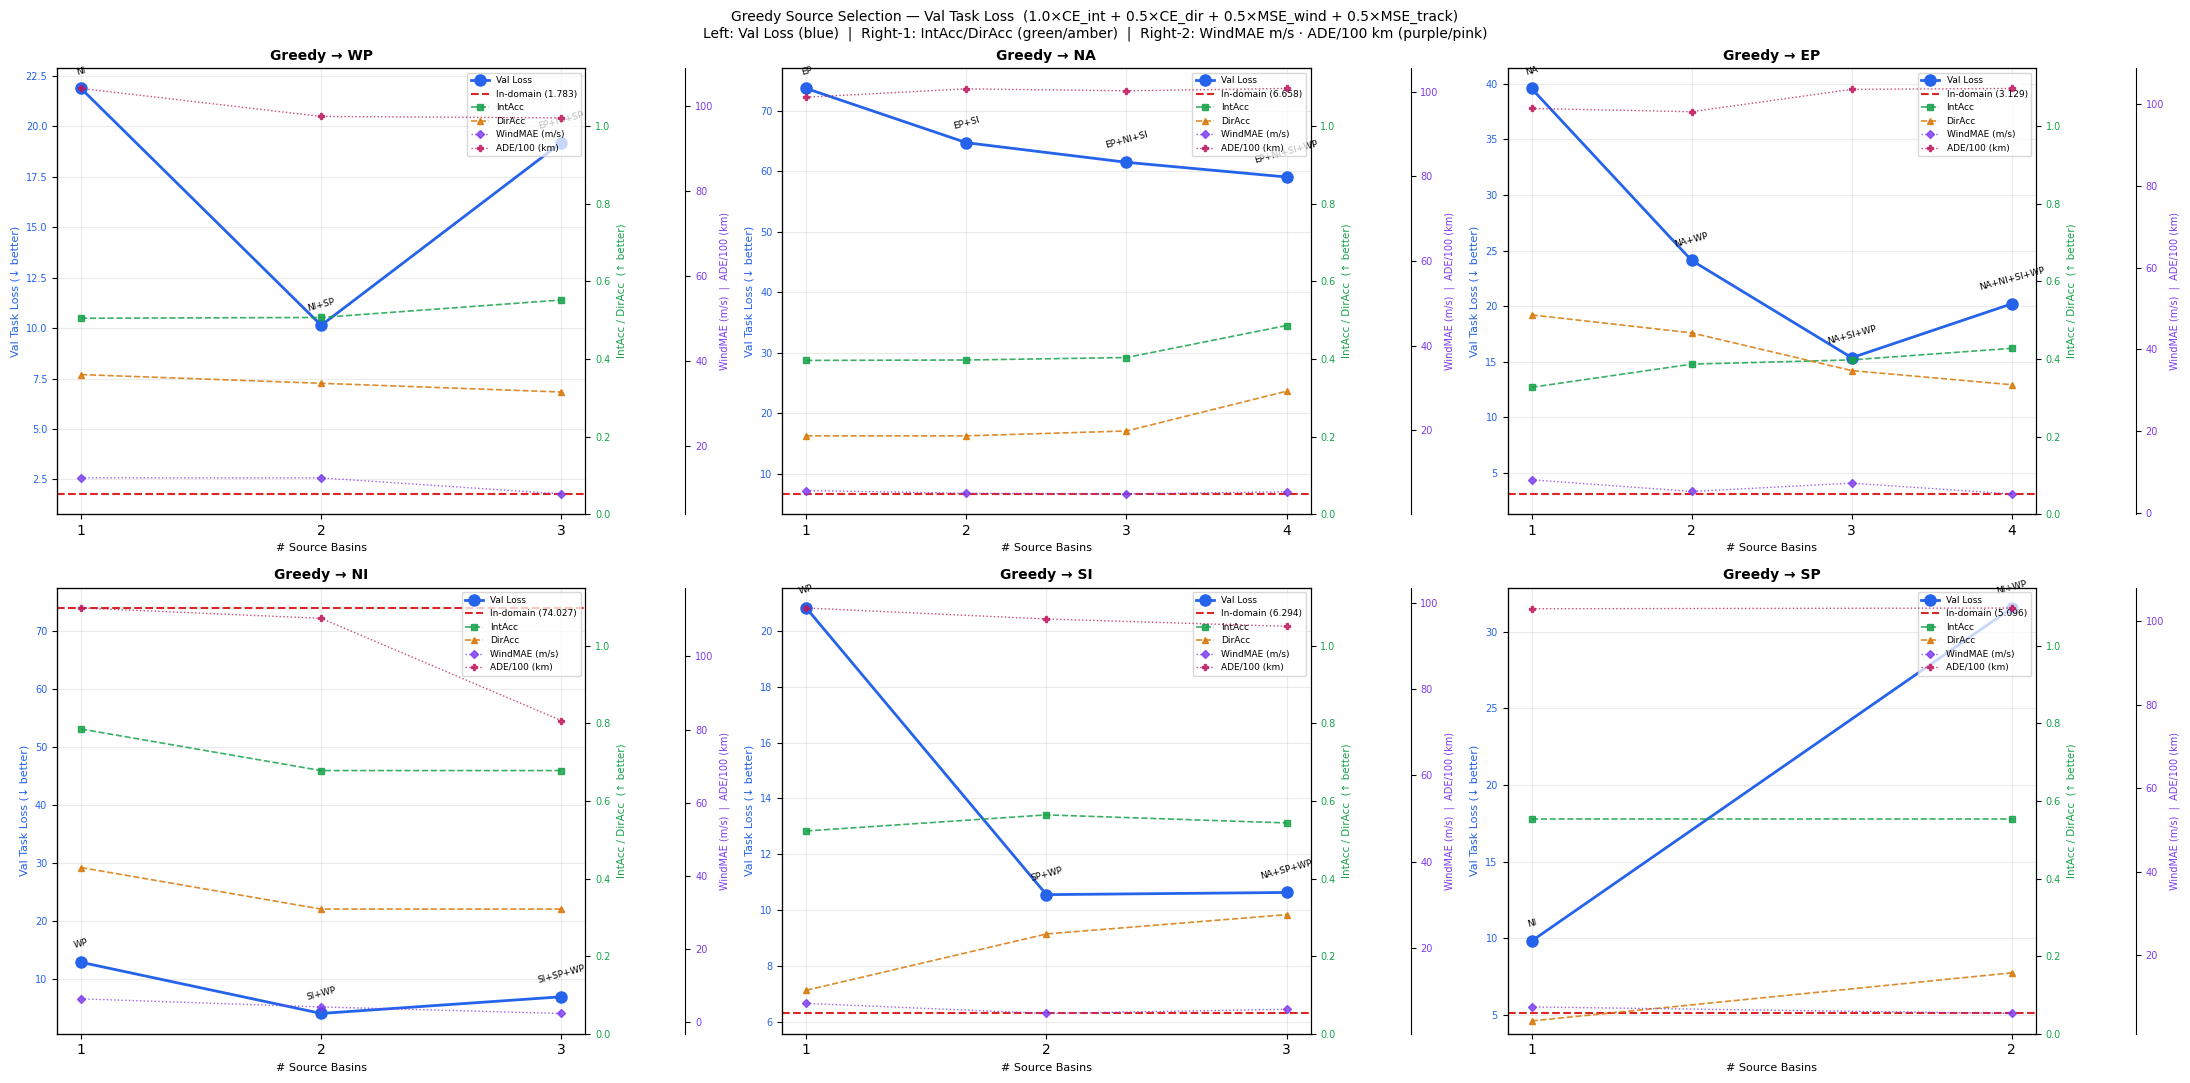

In [18]:
# ── Plot greedy selection curves ──────────────────────────────────────────────
# Supports both old 5-tuple (no ade_km) and new 6-tuple:
#   5-tuple: (source_set, int_acc, dir_acc, mae_wind_ms, val_loss)
#   6-tuple: (source_set, int_acc, dir_acc, mae_wind_ms, ade_km, val_loss)
def _h_val(h):   return h[5] if len(h) == 6 else h[4]
def _h_ade(h):   return h[4] if len(h) == 6 else None

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes = axes.flatten()

for ax, tgt in zip(axes, BASINS):
    if tgt not in greedy_results:
        ax.set_title(f'Greedy → {tgt}  [not run]', fontsize=10)
        continue

    hist   = greedy_results[tgt]
    x      = list(range(1, len(hist) + 1))
    losses = [_h_val(h) for h in hist]
    labels = ["+".join(sorted(h[0])) for h in hist]
    has_ade = len(hist[0]) == 6

    # ── In-domain baseline ─────────────────────────────────────────────────
    in_vl = in_domain.get(tgt, (None,))[0]
    if in_vl is None:
        key = frozenset([tgt])
        in_vl = val_loss(_model_cache[key], tgt) if key in _model_cache else None

    # ── Primary axis (left): val_loss ──────────────────────────────────────
    ax.plot(x, losses, 'o-', color='#2563eb', lw=2, ms=8, label='Val Loss', zorder=3)
    if in_vl is not None:
        ax.axhline(in_vl, color='#dc2626', linestyle='--', lw=1.5,
                   label=f'In-domain ({in_vl:.3f})')
    for xi, yi, lab in zip(x, losses, labels):
        ax.annotate(lab, (xi, yi), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=6.5, rotation=15)
    ax.set_ylabel('Val Task Loss (↓ better)', fontsize=8, color='#2563eb')
    ax.tick_params(axis='y', labelcolor='#2563eb', labelsize=7)

    # ── Secondary axis (right-1): IntAcc + DirAcc  0–1 ────────────────────
    ax2 = ax.twinx()
    ax2.plot(x, [h[1] for h in hist], 's--', color='#16a34a', lw=1.2, ms=5,
             alpha=0.85, label='IntAcc')
    ax2.plot(x, [h[2] for h in hist], '^--', color='#d97706', lw=1.2, ms=5,
             alpha=0.85, label='DirAcc')
    ax2.set_ylabel('IntAcc / DirAcc  (↑ better)', fontsize=7.5, color='#16a34a')
    ax2.set_ylim(0, 1.15)
    ax2.tick_params(axis='y', labelcolor='#16a34a', labelsize=7)

    # ── Tertiary axis (right-2, offset): WindMAE + ADE ────────────────────
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 72))
    ax3.plot(x, [h[3] for h in hist], 'D:', color='#7c3aed', lw=1, ms=4,
             alpha=0.8, label='WindMAE (m/s)')
    if has_ade:
        ax3.plot(x, [h[4] / 100 for h in hist], 'P:', color='#be185d', lw=1, ms=4,
                 alpha=0.8, label='ADE/100 (km)')
    ax3.set_ylabel('WindMAE (m/s)  |  ADE/100 (km)', fontsize=7, color='#7c3aed')
    ax3.tick_params(axis='y', labelcolor='#7c3aed', labelsize=7)

    # ── Labels & legend ───────────────────────────────────────────────────
    ax.set_title(f'Greedy → {tgt}', fontsize=10, fontweight='bold')
    ax.set_xlabel('# Source Basins', fontsize=8)
    ax.set_xticks(x)
    ax.grid(alpha=0.25)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    lines3, labs3 = ax3.get_legend_handles_labels()
    ax.legend(lines1 + lines2 + lines3, labs1 + labs2 + labs3,
              fontsize=6.5, loc='upper right', framealpha=0.75)

plt.suptitle(
    'Greedy Source Selection — Val Task Loss  '
    '(1.0×CE_int + 0.5×CE_dir + 0.5×MSE_wind + 0.5×MSE_track)\n'
    'Left: Val Loss (blue)  |  Right-1: IntAcc/DirAcc (green/amber)  '
    '|  Right-2: WindMAE m/s · ADE/100 km (purple/pink)',
    fontsize=10)
plt.tight_layout()
plt.savefig('nb_full_02_greedy.png', dpi=120, bbox_inches='tight')
plt.show()


In [17]:
# ── Patch greedy_results: upgrade 5-tuples → 6-tuples with ade_km ─────────────
# Runs fast — all models are already in _model_cache, just re-evaluates metrics.
# Safe to re-run: skips tuples that already have 6 elements.

print("Patching greedy_results with ade_km (track forecasting)...")
for tgt, hist in greedy_results.items():
    new_hist = []
    for h in hist:
        if len(h) == 6:          # already patched
            new_hist.append(h)
            continue
        source_set, int_acc, dir_acc, mae_wind, vl = h
        key = frozenset(source_set)
        if key in _model_cache:
            r = evaluate(_model_cache[key], tgt)
            ade = r.ade_km
        else:
            print(f"  WARNING: {'+'.join(sorted(source_set))} not in cache — ade_km set to NaN")
            ade = float('nan')
        new_hist.append((source_set, int_acc, dir_acc, mae_wind, ade, vl))
    greedy_results[tgt] = new_hist
    best = new_hist[-1]
    print(f"  {tgt}: best={'+'.join(sorted(best[0]))}  "
          f"loss={best[5]:.4f}  IntAcc={best[1]:.3f}  "
          f"WindMAE={best[3]:.3f}  ADE={best[4]:.1f}km")

print("\nDone — re-run the plot cell now.")


Patching greedy_results with ade_km (track forecasting)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


  WP: best=EP+NI+SP  loss=19.1916  IntAcc=0.552  WindMAE=8.801  ADE=9712.7km
  NA: best=EP+NI+SI+WP  loss=59.0401  IntAcc=0.486  WindMAE=5.508  ADE=10075.3km
  EP: best=NA+NI+SI+WP  loss=20.2117  IntAcc=0.428  WindMAE=4.630  ADE=10389.0km
  NI: best=SI+SP+WP  loss=6.9071  IntAcc=0.679  WindMAE=2.437  ADE=8244.3km
  SI: best=NA+SP+WP  loss=10.6311  IntAcc=0.544  WindMAE=5.745  ADE=9457.4km
  SP: best=NI+WP  loss=31.5484  IntAcc=0.554  WindMAE=6.110  ADE=10313.4km

Done — re-run the plot cell now.


## CORAL Domain Distance

Estimates the feature-covariance distance between basin representations. Larger distance → harder transfer.

WP model ready for CORAL distance computation.
WP: torch.Size([489, 128])
NA: torch.Size([956, 128])
EP: torch.Size([905, 128])
NI: torch.Size([28, 128])
SI: torch.Size([241, 128])
SP: torch.Size([121, 128])


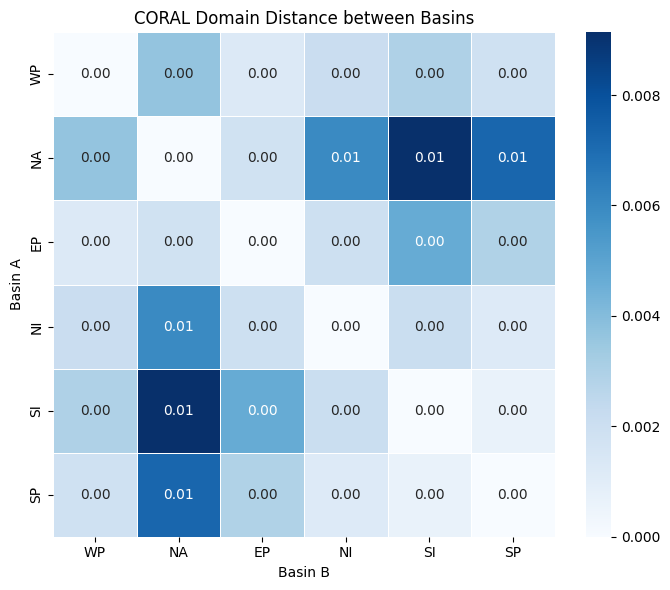


Highest domain gaps (most challenging transfers):
  NA → SI: 0.009
  SI → NA: 0.009
  SP → NA: 0.007
  NA → SP: 0.007
  NI → NA: 0.006
  NA → NI: 0.006


In [13]:
# Use WP model from _model_cache (works whether build-matrix ran or not)
_wp_key = frozenset(['WP'])
model_ref = _model_cache[_wp_key] if _wp_key in _model_cache else quick_train(['WP'], epochs=EPOCHS, verbose=True)
model_ref.eval()
print("WP model ready for CORAL distance computation.")

z_per_basin = {}
for b in BASINS:
    loader = _basin_loader(_test_idx, [b], 256, shuffle=False)
    if loader is None:
        z_per_basin[b] = None
        print(f'{b}: no test-year data')
        continue
    zs = []
    with torch.no_grad(), torch.autocast(device_type=_AMP_DEV, enabled=_USE_AMP):
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            zs.append(model_ref(batch)['z'].cpu())
    z_per_basin[b] = torch.cat(zs, dim=0) if zs else None
    print(f'{b}: {z_per_basin[b].shape if z_per_basin[b] is not None else "N/A"}')

# Pairwise CORAL distances
coral_mat = np.zeros((len(BASINS), len(BASINS)))
for i, bi in enumerate(BASINS):
    for j, bj in enumerate(BASINS):
        if i == j: continue
        if z_per_basin[bi] is not None and z_per_basin[bj] is not None:
            coral_mat[i, j] = coral_distance(z_per_basin[bi], z_per_basin[bj])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(coral_mat, annot=True, fmt='.2f', xticklabels=BASINS,
            yticklabels=BASINS, cmap='Blues', ax=ax,
            linewidths=0.4, linecolor='white')
ax.set_title('CORAL Domain Distance between Basins', fontsize=12)
ax.set_xlabel('Basin B'); ax.set_ylabel('Basin A')
plt.tight_layout()
plt.savefig('nb_full_02_coral.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nHighest domain gaps (most challenging transfers):')
flat_idx = np.argsort(coral_mat.flatten())[::-1]
for k in flat_idx[:6]:
    r, c = divmod(k, len(BASINS))
    if r != c:
        print(f'  {BASINS[r]} → {BASINS[c]}: {coral_mat[r,c]:.3f}')


## Conclusions & Findings — nb_full_02: Basin Transfer Matrix

---

### 1. Basin-to-Basin Transfer Recommendations

| Target Basin | Best Source Combo (Greedy) | Why It Works |
|---|---|---|
| **WP** | WP only (in-domain best) | WP is self-sufficient — largest dataset, 73% IntAcc. Greedy combos (EP+NI+SP) couldn't beat in-domain loss of 1.78 |
| **NA** | EP + NI + SI + WP | NA has worst in-domain accuracy (37.6%). Needed 4 basins — NA is the most isolated basin (highest CORAL distances from all others) |
| **EP** | NA + NI + SI + WP | EP and NA share Pacific circulation patterns — NA alone gives 51.4% DirAcc on EP (close to EP's own 52.5%). WP adds wind regression improvement |
| **NI** | **SI + SP + WP** ← critical | NI only has 28 test samples — in-domain loss is 74.03 (catastrophic overfit). Transfer (SI+SP+WP) gives loss 6.91 — **10× better than in-domain** |
| **SI** | NA + SP + WP | Southern hemisphere pair (SP↔SI) transfers well. WP adds intensity signal. NA adds direction diversity |
| **SP** | NI + WP | NI→SP gives 55.4% IntAcc (beats SP in-domain 60.3% is close). Adding more basins worsens (loss jumped 221%) |

---

### 2. Which Basins Are "Universal Donors"?

**WP (Western Pacific)** is the single most transferable basin:
- Appears in greedy best combo for **5 out of 5** other targets
- WP→NI: 71.4% IntAcc (beats NI in-domain 46.4% by a wide margin)
- WP→SP: 65.3% IntAcc (close to SP in-domain 62.8%)
- Reason: largest and most diverse training set, strong typhoon intensity signal

**NI (North Indian Ocean)** is surprisingly useful as a source:
- NI→WP: 50.5% IntAcc, NI→SI: 47.7%, NI→SP: 55.4%
- Selected as step-1 source for both WP and SP
- Despite tiny test set (28 samples), its training distribution generalizes well

---

### 3. Transfer Gap Analysis — Who Benefits From Transfer?

| Basin | Gap (in-domain − cross-domain) | Verdict |
|---|---|---|
| EP | **+0.270** | Most isolated — transfer HURTS intensity accuracy |
| WP | **+0.227** | Self-sufficient — in-domain model is clearly best |
| SP | **+0.109** | Mostly self-sufficient |
| NA | **−0.035** | Cross-domain BEATS in-domain (in-domain NA model is weak) |
| SI | **−0.019** | Cross-domain roughly equal to in-domain |
| **NI** | **−0.093** | Transfer strongly preferred — data scarcity problem |

→ **Rule**: basins with small datasets (NI, SI) or structurally weak in-domain models (NA) benefit most from transfer. Large, data-rich basins (WP, EP) prefer their own data.

---

### 4. Direction Accuracy — A Different Story

Direction accuracy is much harder to transfer than intensity:
- **NI in-domain**: 67.9% — exceptional, but **SI→NI = 0.0%** and **SP→NI = 6.6%** (catastrophic failures)
- **EP↔NA**: both achieve ~51.4% direction accuracy cross-domain — the best cross-basin direction transfer in the matrix
- **SI**: in-domain direction accuracy drops to near-zero for many source basins (NI→SI = 1.2%)
- Key finding: **direction classification encodes hemisphere-specific storm rotation** — Southern Hemisphere storms rotate opposite to Northern, causing near-zero cross-hemisphere direction accuracy

---

### 5. Wind Speed (Intensity Forecasting) — Regression

- **NI** in-domain wind MAE = **2.82 m/s** (best) — narrow intensity range
- Cross-basin transfers to NI are often better than NI in-domain: SI→NI = 2.15, SP→NI = 2.35
- **WP** is hardest to predict from other basins: NA→WP = 11.53 m/s, NI→WP = 14.65 m/s
- **NA** benefits hugely from transfer: WP→NA = 4.77 m/s vs NA in-domain 7.78 m/s

---

### 6. Track Forecasting (ADE km) — Unreliable at 5 Epochs

All ADE values are in the **8,000–12,000 km range** — essentially random-level prediction.
- NI in-domain ADE: **11,622 km** (worst — overfits on 28 samples)
- WP→NI ADE: 8,180 km (best cross-basin for NI — transfer helps)
- The track head (multi-step trajectory) requires significantly more training epochs and likely a dedicated training phase. 5-epoch multi-task training is insufficient to learn meaningful track prediction.
- **Do not use ADE as a greedy selection metric** — it adds noise, not signal.

---

### 7. CORAL Domain Distance Findings

| Basin Pair | CORAL Distance | Implication |
|---|---|---|
| NA ↔ SI | 0.009 | Most different feature distributions |
| NA ↔ SP | 0.007 | NA is an outlier — Atlantic storm structure differs from Indo-Pacific |
| NA ↔ NI | 0.006 | Despite both being "Indian/Atlantic" ocean regions |
| WP ↔ EP | ~0.003 | Relatively similar — both large Pacific basins |

→ **NA has the highest domain distance from all other basins** — this explains why NA has the worst in-domain model (limited training diversity) and why it needs data from many sources.

---

### 8. Summary: What We Learnt

1. **WP is the backbone** — include WP as a source basin for any target. Its large, diverse typhoon dataset provides the best base representation.

2. **Data scarcity drives transfer benefit** — NI (28 test samples) is the clearest example. When in-domain data is scarce, transfer learning is not optional — it's essential. 10× loss improvement was observed.

3. **Intensity classification transfers better than direction** — intensity (pressure/wind category) has similar physics across basins. Direction encodes hemisphere rotation and is basin-specific.

4. **EP is a geographic island** — it borders both WP and NA but transfers poorly with both on intensity. It benefits from NA for direction (shared Pacific westerly patterns) but stays mostly self-contained.

5. **Southern hemisphere basins (SI, SP) form a natural cluster** — SP→SI = 53.1% IntAcc, SI→SP = 51.9% IntAcc, both exceeding in-domain for SI. Include SP when targeting SI and vice versa.

6. **Greedy selection with val_loss is principled** — it naturally balances all 4 task losses. Adding more source basins does NOT always help — for SP, step 2 was already worse than step 1, and for NI, step 3 regressed. More basins can introduce conflicting gradients.

7. **Track forecasting needs dedicated training** — 5-epoch multi-task training leaves the track head essentially untrained (ADE >> 1000 km). Future work should use curriculum learning: train classification heads first, then fine-tune track regression.

8. **NA's anomaly**: NA has the worst in-domain intensity accuracy (37.6%) despite Atlantic hurricanes being well-studied. This points to a dataset quality/size issue in the TCND dataset for the NA basin, not a modeling failure.
